# Judul Proyek: Peramalan Cuaca Real-time untuk Mendukung Aktivitas Kampus UNSRAT Berbasis Machine Learning dan Pipeline Data Otomatis



## Business Understanding

1. Bagaimana seorang mahasiswa UNSRAT bisa membuat keputusan harian yang lebih baik (seperti 'perlu bawa payung atau tidak') untuk menghadapi kondisi cuaca kampus yang sering berubah secara mendadak?
2. Untuk memutuskan 'membawa payung', informasi apa yang sebenarnya dibutuhkan? Apakah hanya 'ya/tidak' akan hujan, atau mereka butuh data yang lebih detail seperti 'berapa suhunya' dan 'seberapa deras hujannya'?
3. Bagaimana pengguna bisa percaya bahwa prediksi yang mereka lihat bukan data basi dari kemarin, tetapi benar-benar relevan dengan kondisi saat ini?
4. Pengguna tidak mau repot menganalisis angka (misal: 'apa arti curah hujan 1.5 mm?'). Bisakah sistem memberikan rekomendasi langsung yang bisa ditindaklanjuti?
5. Seberapa jauh ke depan seorang mahasiswa perlu melihat prediksi agar relevan untuk aktivitas mereka di kampus? Apakah cukup 1 jam, atau mereka perlu perencanaan untuk sore hari?



## Data Understanding

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

import xgboost as xgb
from xgboost import XGBRegressor, XGBClassifier


### Load Data

In [ ]:
url = "https://raw.githubusercontent.com/witaa07/ML_PROJECT/main/dataset/data_cuaca_manado_2020_2025.csv"
data = pd.read_csv(url, header=2)

### Exploratory Data Analysis (EDA)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   time                      43848 non-null  object 
 1   temperature_2m (°C)       43848 non-null  float64
 2   relative_humidity_2m (%)  43848 non-null  int64  
 3   weather_code (wmo code)   43848 non-null  int64  
 4   rain (mm)                 43848 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 1.7+ MB


In [ ]:
data.head()

,time,temperature_2m (°C),relative_humidity_2m (%),weather_code (wmo code),rain (mm)
0,2020-11-13T00:00,29.0,71,1,0.0
1,2020-11-13T01:00,30.5,63,2,0.0
2,2020-11-13T02:00,31.3,62,1,0.0
3,2020-11-13T03:00,31.3,63,51,0.4
4,2020-11-13T04:00,30.8,68,53,0.5


In [ ]:
data.describe(include='all')

,time,temperature_2m (°C),relative_humidity_2m (%),weather_code (wmo code),rain (mm)
count,43848,43848.000000,43848.000000,43848.000000,43848.000000
unique,43848,NaN,NaN,NaN,NaN
top,2025-11-13T23:00,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,26.509877,85.461253,23.645731,0.342880
std,NaN,2.138321,9.596085,25.245622,1.121693
min,NaN,21.300000,34.000000,0.000000,0.000000
25%,NaN,24.900000,81.000000,3.000000,0.000000
50%,NaN,25.900000,88.000000,3.000000,0.000000
75%,NaN,27.900000,92.000000,51.000000,0.200000


In [ ]:
data.isnull().sum()

,0
time,0
temperature_2m (°C),0
relative_humidity_2m (%),0
weather_code (wmo code),0
rain (mm),0


In [ ]:
data.duplicated().sum()

np.int64(0)

<Axes: xlabel='temperature_2m (°C)'>

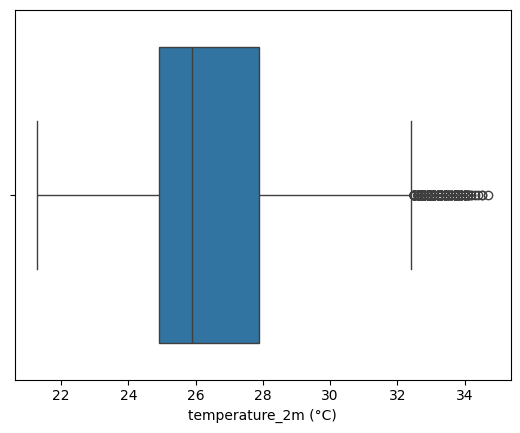

In [ ]:
sns.boxplot(x=data['temperature_2m (°C)'])

<Axes: xlabel='relative_humidity_2m (%)'>

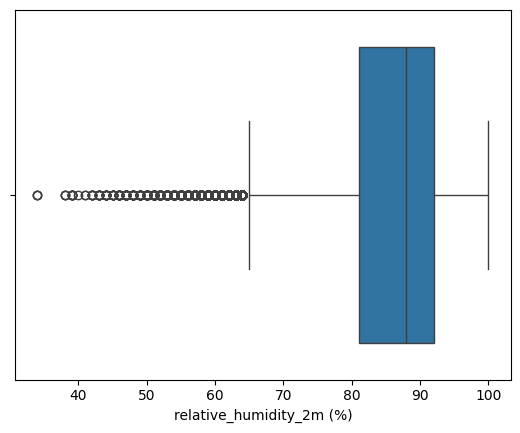

In [ ]:
sns.boxplot(x=data['relative_humidity_2m (%)'])

<Axes: xlabel='weather_code (wmo code)'>

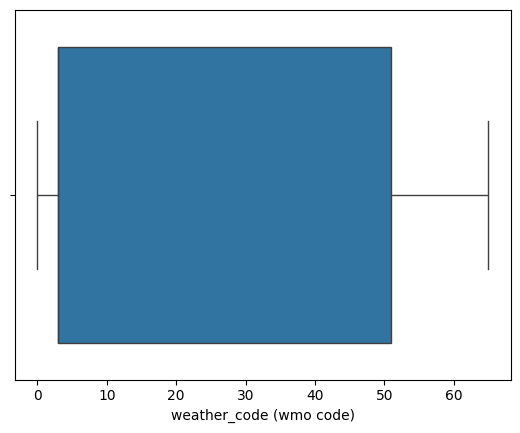

In [ ]:
sns.boxplot(x=data['weather_code (wmo code)'])

<Axes: xlabel='rain (mm)'>

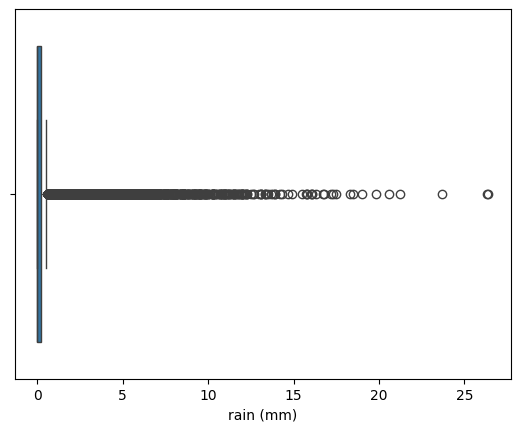

In [ ]:
sns.boxplot(x=data['rain (mm)'])

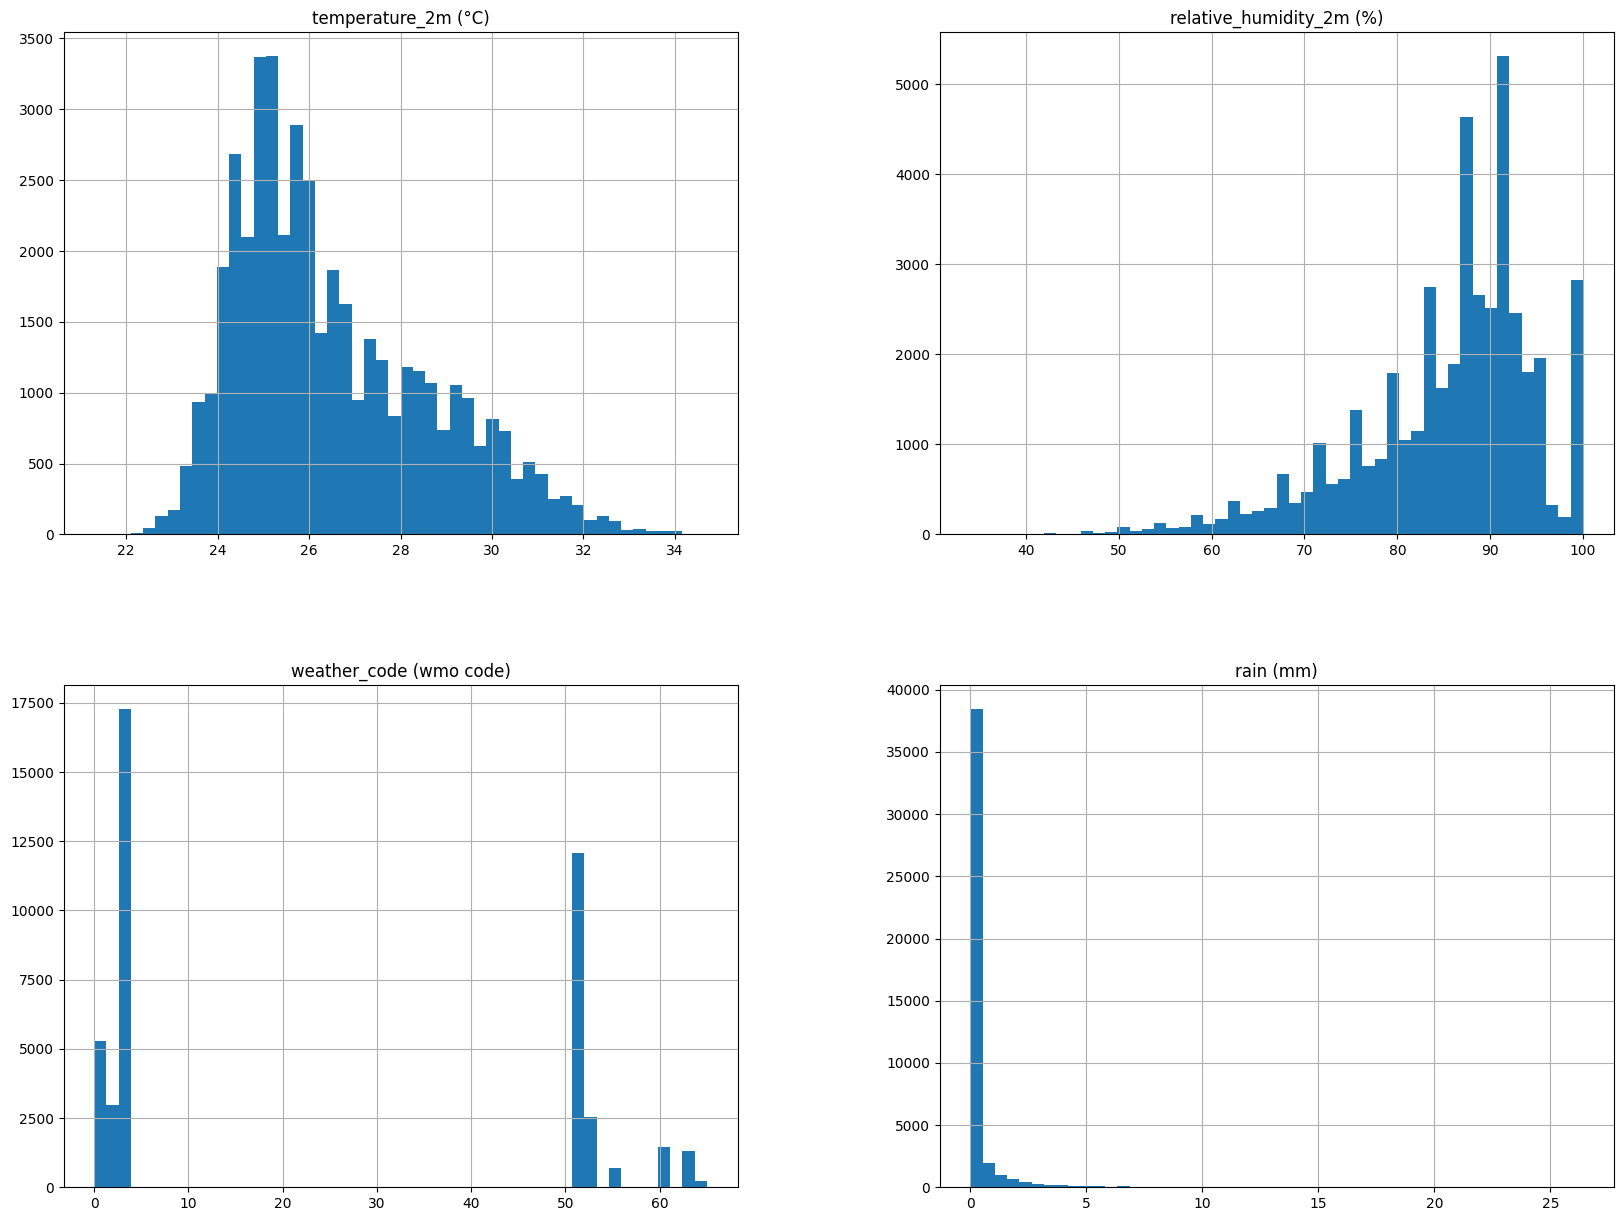

In [ ]:
data.hist(bins=50, figsize=(20,15))
plt.show()

Interpretasi :

Analisis data historis (EDA) kami menunjukkan bahwa distribusi suhu (temperature_2m) mendekati normal, menjadikannya target yang ideal untuk Model Regresi A. Sebaliknya, kode cuaca (weather_code) terbukti sangat tidak seimbang (imbalanced), dengan mayoritas data terkonsentrasi pada kode 'Cerah' atau 'Berawan'. Hal ini mengkonfirmasi bahwa melatih model klasifikasi pada weather_code akan menghasilkan prediksi yang bias dan tidak akurat untuk mendeteksi hujan. Oleh karena itu, kami akan menggunakan curah hujan (rain (mm)) sebagai target untuk Model Regresi B; meskipun datanya sangat condong (zero-inflated) karena sebagian besar waktu tidak hujan, ini adalah representasi yang jauh lebih baik untuk memprediksi 'apakah akan hujan' dan 'seberapa deras' secara bersamaan.

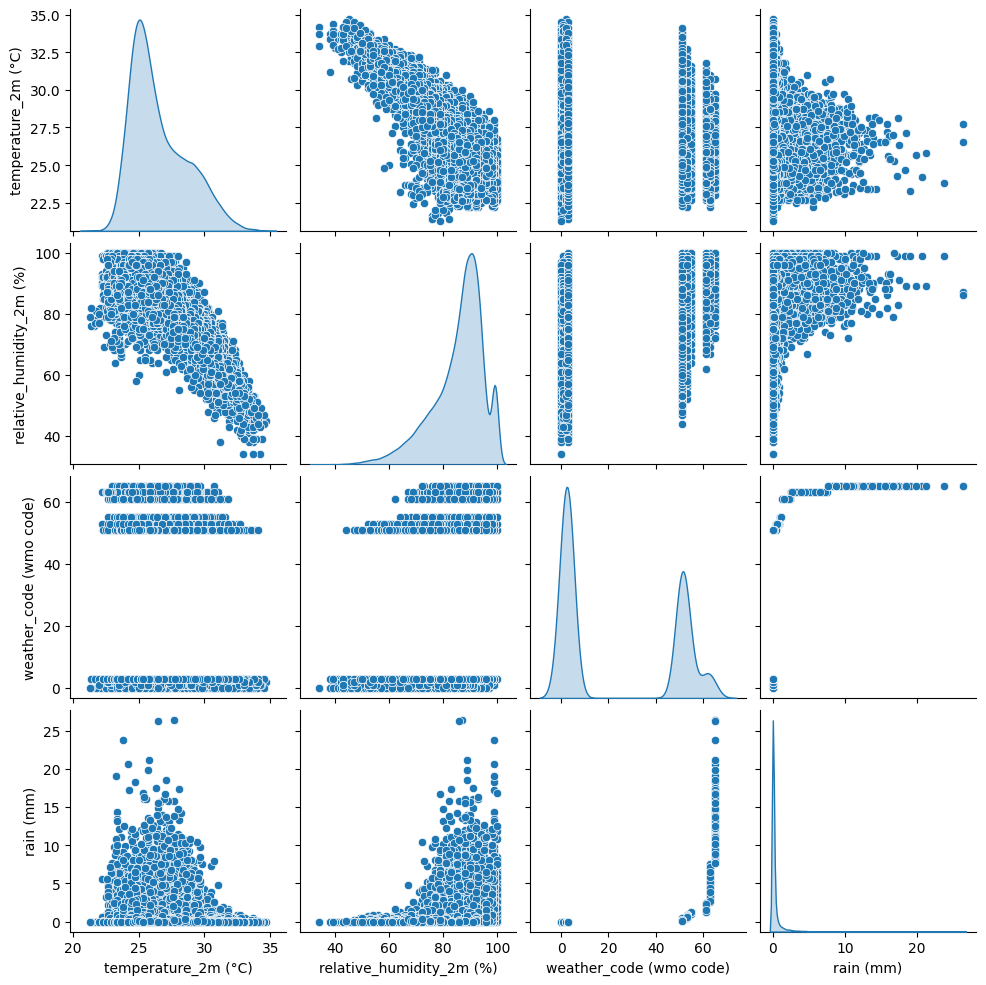

In [ ]:
# Mengamati hubungan antar fitur numerik dengan fungsi pairplot()
sns.pairplot(data, diag_kind='kde')

Interpretasi:

Visualisasi pairplot ini mengkonfirmasi temuan dari histogram dan memberikan wawasan krusial tentang korelasi antar variabel. Kami mengidentifikasi hubungan prediktif yang kuat yang akan sangat penting untuk model kami. Secara spesifik, plot ini menunjukkan bahwa curah hujan (rain (mm)) hampir secara eksklusif terjadi hanya ketika suhu lebih rendah (di bawah 30°C) dan kelembapan relatif sangat tinggi (di atas 85%). Hubungan yang jelas antara suhu, kelembapan, dan hujan ini memberikan sinyal yang kuat bagi model regresi kami untuk belajar, sehingga meningkatkan kepercayaan diri kami dalam akurasi prediksi.

Text(0.5, 1.0, 'Correlation Matrix')

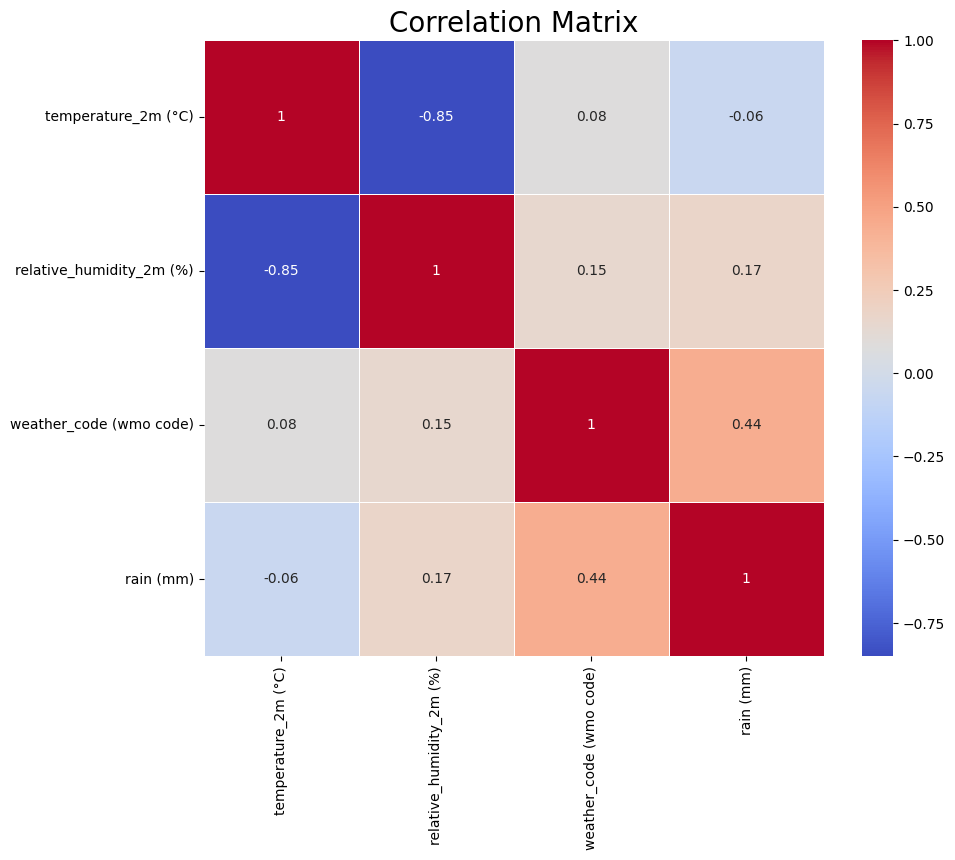

In [ ]:
plt.figure(figsize=(10,8))
correlation_matrix =  data.iloc[:, 1:].corr().round(2)
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, )
plt.title("Correlation Matrix", size=20)

Interpretasi:

Matriks korelasi ini memberikan pengukuran kuantitatif atas hubungan antar variabel kami. Temuan yang paling signifikan adalah korelasi negatif yang sangat kuat (-0.85) antara suhu dan kelembapan, yang menegaskan bahwa keduanya adalah prediktor kuat satu sama lain. Selain itu, korelasi positif sedang (0.44) antara weather_code dan rain (mm) membuktikan bahwa weather_code akan menjadi fitur input yang berharga untuk memprediksi curah hujan. Korelasi yang tampak lemah, seperti antara suhu dan hujan (-0.06), menyoroti sifat non-linear dari data cuaca, yang memperkuat kebutuhan akan model machine learning yang dapat menangkap pola yang lebih kompleks daripada sekadar hubungan linear sederhana.

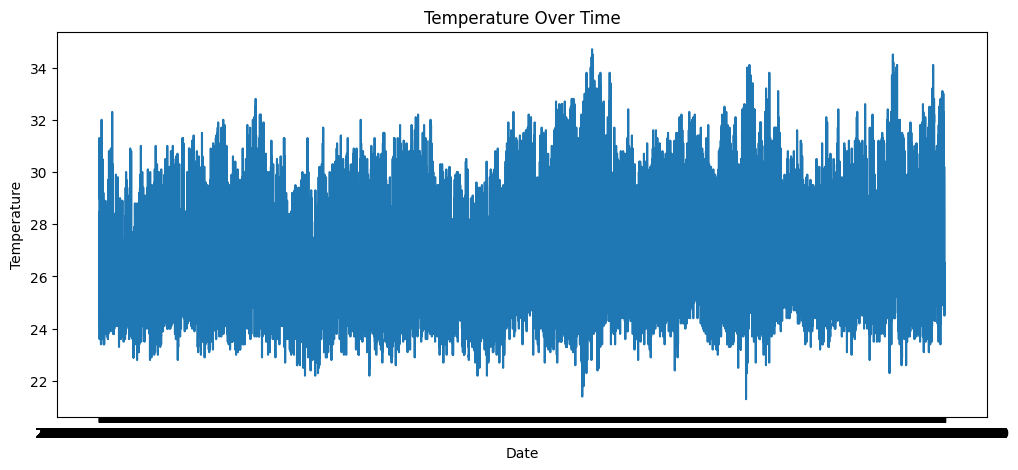

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(data['time'], data['temperature_2m (°C)'])
plt.title("Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

Interpretasi:

Plot time-series dari suhu historis ini sangat penting, karena secara visual mengkonfirmasi adanya pola musiman ganda (dual seasonality). Pola osilasi frekuensi tinggi yang jelas menunjukkan musiman harian (siklus siang-malam), sementara gelombang yang lebih lambat dan lebih besar menunjukkan musiman tahunan (perbedaan antar bulan/musim). Kehadiran kedua pola siklus yang kuat ini menegaskan bahwa data ini sangat ideal untuk dimodelkan.

<Axes: title={'center': 'Total Monthly Rainfall'}, xlabel='Month', ylabel='Rainfall'>

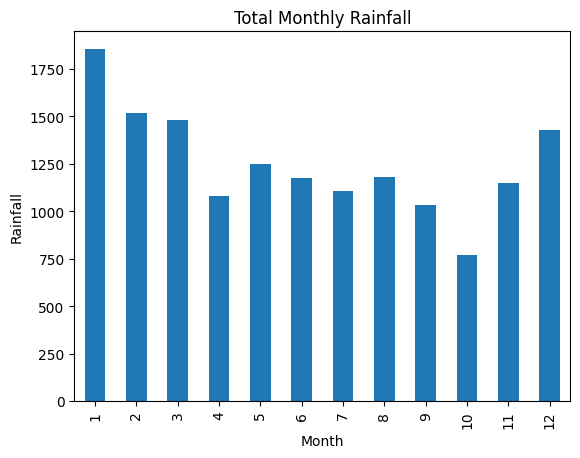

In [ ]:
data.groupby('bulan')['rain (mm)'].sum().plot(kind='bar', xlabel='Month', ylabel='Rainfall', title='Total Monthly Rainfall')


Interpretasi:

Plot total curah hujan bulanan ini secara definitif mengkonfirmasi adanya pola musiman tahunan (yearly seasonality) yang kuat. Terdapat musim hujan yang jelas di awal tahun (mencapai puncak di bulan Januari) dan musim kemarau yang jelas di pertengahan hingga akhir tahun (mencapai titik terendah di bulan Oktober). Temuan ini sangat krusial karena menegaskan bahwa fitur bulan adalah fitur yang wajib dibuat; model machine learning kita harus diajarkan fitur ini agar dapat membedakan secara fundamental antara pola cuaca di bulan Januari dan pola cuaca di bulan Oktober.

## Data Preparation

In [ ]:
data['time'] = pd.to_datetime(data['time'])

In [ ]:
# Change to local time
data['time'] = data['time'].dt.tz_localize('UTC')
data['time'] = data['time'].dt.tz_convert('Asia/Makassar')

### Features Engineering

In [ ]:
# Kolom Bulan
data['bulan'] = data['time'].dt.month

In [ ]:
# Kolom jam
data['jam_dalam_hari'] = data['time'].dt.hour

In [ ]:
data['jam_dalam_hari'].unique()

array([ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,  0,
        1,  2,  3,  4,  5,  6,  7], dtype=int32)

In [ ]:
# Kolom hari
data['hari_dalam_minggu'] = data['time'].dt.dayofweek
data['hari_dalam_minggu'].unique()

array([4, 5, 6, 0, 1, 2, 3], dtype=int32)

In [ ]:
# Kolom Suhu 24 jam lalu
data['suhu_24jam_lalu'] = data['temperature_2m (°C)'].shift(24)

# Kolom Suhu 1 jam lalu
data['suhu_1jam_lalu'] = data['temperature_2m (°C)'].shift(1)

# Kolom Suhu 2 jam lalu
data['suhu_2jam_lalu'] = data['temperature_2m (°C)'].shift(2)

# Kolom Suhu 3 jam lalu
data['suhu_3jam_lalu'] = data['temperature_2m (°C)'].shift(3)

# Kolom kelembapan_24jam_lalu
data['kelembapan_24jam_lalu'] = data['relative_humidity_2m (%)'].shift(24)

# Kolom rain_24jam_lalu
data['rain_24jam_lalu'] = data['rain (mm)'].shift(24)



In [ ]:
data = data.dropna().reset_index(drop=True)

Pada tahap Feature Engineering, dilakukan penambahan fitur baru dari variabel waktu dan variabel cuaca untuk meningkatkan kemampuan model dalam memahami pola cuaca. Kolom waktu diuraikan menjadi bulan, jam dalam hari, dan hari dalam minggu, karena kondisi cuaca sangat dipengaruhi oleh faktor musiman dan siklus harian. Selain itu, ditambahkan pula fitur lag seperti suhu dan kelembapan pada 24 jam sebelumnya, serta suhu pada 1–3 jam sebelumnya. Fitur-fitur lag ini penting karena cuaca bersifat autocorrelated, artinya kondisi saat ini sangat dipengaruhi kondisi waktu sebelumnya. Penambahan fitur rain 24 jam lalu juga membantu model mendeteksi pola probabilitas hujan. Setelah semua fitur dibuat, dilakukan drop missing values karena operasi shift menghasilkan nilai kosong di baris awal. Dengan fitur-fitur ini, model dapat belajar pola perubahan cuaca lebih baik dan menghasilkan prediksi yang lebih akurat.

### Rename Column Name

In [ ]:
data.rename(columns={'time' : 'Waktu', 'temperature_2m (°C)': 'Suhu', 'relative_humidity_2m (%)' : 'Kelembapan', 'weather_code (wmo code)' : 'DeskripsiCuaca',
                     'rain (mm)' : 'CurahHujan','rain_24jam_lalu': 'CurahHujan_24jam_lalu'}, inplace=True)

In [ ]:
data.head()

,Waktu,Suhu,Kelembapan,DeskripsiCuaca,CurahHujan,bulan,jam_dalam_hari,hari_dalam_minggu,suhu_24jam_lalu,suhu_1jam_lalu,suhu_2jam_lalu,suhu_3jam_lalu,kelembapan_24jam_lalu,CurahHujan_24jam_lalu
0,2020-11-14 08:00:00+08:00,27.2,90,53,0.6,11,8,5,29.0,26.2,25.0,23.6,71.0,0.0
1,2020-11-14 09:00:00+08:00,28.2,89,55,1.0,11,9,5,30.5,27.2,26.2,25.0,63.0,0.0
2,2020-11-14 10:00:00+08:00,27.6,87,63,4.3,11,10,5,31.3,28.2,27.2,26.2,62.0,0.0
3,2020-11-14 11:00:00+08:00,27.7,86,61,1.6,11,11,5,31.3,27.6,28.2,27.2,63.0,0.4
4,2020-11-14 12:00:00+08:00,28.5,87,51,0.3,11,12,5,30.8,27.7,27.6,28.2,68.0,0.5


###Labelling untuk Klasifikasi

In [ ]:
def kategori_hujan(mm):
    if mm == 0: return 0
    elif mm <= 5: return 1
    else: return 2

df_model = data.copy()
df_model['Kelas_Hujan'] = df_model['CurahHujan'].apply(kategori_hujan)

# Cek sebaran data (Penting untuk mengetahui imbalance)
print("\nSebaran Kelas Hujan:")
print(df_model['Kelas_Hujan'].value_counts())


Sebaran Kelas Hujan:
Kelas_Hujan
0    25505
1    17767
2      552
Name: count, dtype: int64


Pada tahap Labelling untuk Klasifikasi, data curah hujan yang awalnya berupa nilai numerik (mm) diubah menjadi kategori atau kelas untuk mendukung pemodelan klasifikasi cuaca. Fungsi kategori_hujan() dibuat untuk mengelompokkan curah hujan menjadi tiga kelas: 0 untuk tidak hujan (mm = 0), 1 untuk hujan ringan (mm ≤ 5), dan 2 untuk hujan sedang–lebat (mm > 5). Pendekatan kategorisasi ini memudahkan model dalam memberikan prediksi berbasis tingkat intensitas hujan yang lebih relevan bagi pengguna, misalnya dalam pengambilan keputusan aktivitas di lingkungan kampus. Setelah labelling dilakukan, diperiksa sebaran jumlah data tiap kelas untuk mendeteksi kemungkinan class imbalance, yang terlihat pada hasil bahwa kelas hujan lebat berjumlah jauh lebih sedikit daripada kelas lainnya. Informasi ini penting karena ketidakseimbangan data dapat memengaruhi performa model, sehingga perlu dipertimbangkan strategi penanganannya pada tahap pemodelan.

### Split Dataset

#### Target Suhu (Y)

In [ ]:
train_df = data.loc[data['Waktu'] < '2024-12-01']
val_df   = data.loc[(data['Waktu'] >= '2024-12-01') & (data['Waktu'] < '2025-01-01')]
test_df  = data.loc[data['Waktu'] >= '2025-01-01']

print(f"Jumlah data training: {len(train_df)}")
print(f"Jumlah data testing: {len(test_df)}")
print(f"Jumlah data validation : {len(val_df)}")

Jumlah data training: 35464
Jumlah data testing: 7616
Jumlah data validation : 744


In [ ]:
target_col = 'Suhu'
feature_cols = [c for c in data.columns if c not in ['Waktu', target_col]]

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

#### Target CurahHujan

In [ ]:
train_df = df_model.loc[df_model['Waktu'] < '2024-12-01']
val_df   = df_model.loc[(df_model['Waktu'] >= '2024-12-01') & (df_model['Waktu'] < '2025-01-01')]
test_df  = df_model.loc[df_model['Waktu'] >= '2025-01-01']

In [ ]:
target_col_class = 'Kelas_Hujan'
feature_cols_class = selected_features # Using selected_features from permutation importance for rain

X_train_class = train_df[feature_cols_class].iloc[:-1] # Buang baris terakhir karena shift
y_train_class = train_df[target_col_class].shift(-1).dropna() # Target masa depan

# Pastikan index sama (Align)
X_train_class = X_train_class.loc[y_train_class.index]

print(f"Shape X_train_class: {X_train_class.shape}")
print(f"Shape y_train_class: {y_train_class.shape}")

Shape X_train_class: (35463, 5)
Shape y_train_class: (35463,)


### Feature Selection

#### Permutation Importance

##### Suhu

In [ ]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pi = permutation_importance(
    model,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_squared_error'
)


In [ ]:
pi_mean = pi.importances_mean
pi_std = pi.importances_std

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'pi_mean': pi_mean,
    'pi_std': pi_std
}).sort_values(by='pi_mean', ascending=False)

importance_df

,feature,pi_mean,pi_std
7,suhu_1jam_lalu,1.237110,0.062002
0,Kelembapan,0.641953,0.035730
4,jam_dalam_hari,0.198849,0.015731
6,suhu_24jam_lalu,0.142641,0.009478
10,kelembapan_24jam_lalu,0.031883,0.003274
2,CurahHujan,0.031401,0.004590
9,suhu_3jam_lalu,0.005067,0.001045
8,suhu_2jam_lalu,0.004050,0.001696
1,DeskripsiCuaca,0.003951,0.000720
11,CurahHujan_24jam_lalu,0.001449,0.000589


In [ ]:
top_k = 5
selected_features = importance_df.sort_values(by='pi_mean', ascending=False).head(top_k)['feature'].tolist()
print("Fitur terpilih:", selected_features)

Fitur terpilih: ['suhu_1jam_lalu', 'Kelembapan', 'jam_dalam_hari', 'suhu_24jam_lalu', 'kelembapan_24jam_lalu']


In [ ]:
cols_to_drop = ['Waktu', 'Kelas_Hujan', 'DeskripsiCuaca']
candidate_features = [c for c in data.columns if c not in cols_to_drop]

print("Fitur Kandidat:", candidate_features)

y_train_sel = train_df['Kelas_Hujan'].shift(-1).dropna()
y_val_sel   = val_df['Kelas_Hujan'].shift(-1).dropna()

X_train_sel = train_df.loc[y_train_sel.index][candidate_features]
X_val_sel   = val_df.loc[y_val_sel.index][candidate_features]

probe_model = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=5,
    objective='multi:softprob', num_class=3, random_state=42, n_jobs=-1
)
probe_model.fit(X_train_sel, y_train_sel)

Fitur Kandidat: ['Suhu', 'Kelembapan', 'CurahHujan', 'bulan', 'jam_dalam_hari', 'hari_dalam_minggu', 'suhu_24jam_lalu', 'suhu_1jam_lalu', 'suhu_2jam_lalu', 'suhu_3jam_lalu', 'kelembapan_24jam_lalu', 'CurahHujan_24jam_lalu']


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_class=3, ...)

In [ ]:
perm_results = permutation_importance(
    probe_model, X_val_sel, y_val_sel,
    n_repeats=5, random_state=42, scoring='f1_macro', n_jobs=-1
)

In [ ]:
perm_df = pd.DataFrame({
    'Feature': candidate_features,
    'Importance': perm_results.importances_mean
}).sort_values(by='Importance', ascending=False)

print("\nHasil Feature Importance:")
print(perm_df)


Hasil Feature Importance:
                  Feature  Importance
2              CurahHujan    0.169308
4          jam_dalam_hari    0.013640
1              Kelembapan    0.006294
8          suhu_2jam_lalu    0.001210
5       hari_dalam_minggu    0.000860
11  CurahHujan_24jam_lalu    0.000686
10  kelembapan_24jam_lalu    0.000587
9          suhu_3jam_lalu    0.000552
7          suhu_1jam_lalu    0.000308
6         suhu_24jam_lalu    0.000089
3                   bulan    0.000000
0                    Suhu   -0.000671


In [ ]:
selected_features = perm_df.head(5)['Feature'].tolist()

print(f"\n✅ TOP 5 FITUR TERPILIH: {selected_features}")

# Opsional: Tampilkan skor importance-nya juga agar Anda tahu seberapa kuat mereka
print("\nDetail Skor Top 5:")
print(perm_df.head(5))


✅ TOP 5 FITUR TERPILIH: ['CurahHujan', 'jam_dalam_hari', 'Kelembapan', 'suhu_2jam_lalu', 'hari_dalam_minggu']

Detail Skor Top 5:
             Feature  Importance
2         CurahHujan    0.169308
4     jam_dalam_hari    0.013640
1         Kelembapan    0.006294
8     suhu_2jam_lalu    0.001210
5  hari_dalam_minggu    0.000860


## Modelling & Evaluation

#### XGBoost Regressor

##### Hyperparameter Tuning

In [ ]:
model = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

random_search = RandomizedSearchCV(
    model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print(random_search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
{'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.9}


In [ ]:
best_params = random_search.best_params_

In [ ]:
horizons = [1, 3, 6]
models = {}
results = {}

for h in horizons:
    print(f"\nMelatih Model untuk Target T+{h} Jam...")

    # 2. Buat Target (Y) dengan Shift
    # y_train adalah Series 'Suhu' dari train_df
    y_train_h = train_df['Suhu'].shift(-h).dropna()
    y_val_h   = val_df['Suhu'].shift(-h).dropna()

    # 3. Buat Fitur (X) dengan Index yang Cocok
    X_train_h = train_df.loc[y_train_h.index][selected_features]
    X_val_h   = val_df.loc[y_val_h.index][selected_features]

    # 4. Latih Model
    model_h = xgb.XGBRegressor(
        **best_params,
        random_state=42,
        n_jobs=-1
    )

    model_h.fit(
        X_train_h, y_train_h,
        verbose=False
    )

    models[h] = model_h

    # 5. Evaluasi Vito Kaseger
    # Siapkan data test yang di-shift juga
    y_test_h = test_df['Suhu'].shift(-h).dropna()
    X_test_h = test_df.loc[y_test_h.index][selected_features]

    preds = model_h.predict(X_test_h)
    mae = mean_absolute_error(y_test_h, preds)
    mse = mean_squared_error(y_test_h, preds)
    print(f"--> MAE Model T+{h}: {mae:.3f}°C, MSE: {mse:.3f}")

    ft_importance = pd.Series(model_h.feature_importances_, index=selected_features)
    top_feature = ft_importance.idxmax()
    print(f"    Fitur Terpenting: {top_feature}")

    # PENTING: Mengisi dictionary results
    results[h] = {
        'y_true': y_test_h,
        'y_pred': preds,
        'mae': mae
    }


Melatih Model untuk Target T+1 Jam...
--> MAE Model T+1: 0.451°C, MSE: 0.397
    Fitur Terpenting: Kelembapan

Melatih Model untuk Target T+3 Jam...
--> MAE Model T+3: 0.620°C, MSE: 0.719
    Fitur Terpenting: jam_dalam_hari

Melatih Model untuk Target T+6 Jam...
--> MAE Model T+6: 0.714°C, MSE: 0.944
    Fitur Terpenting: jam_dalam_hari


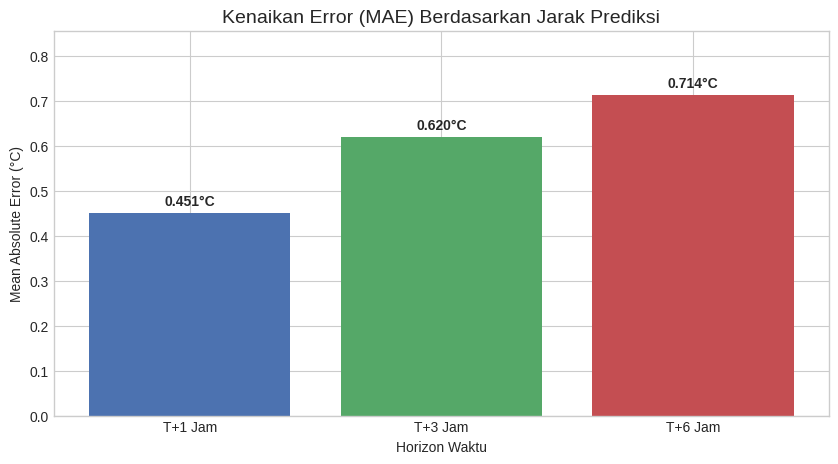

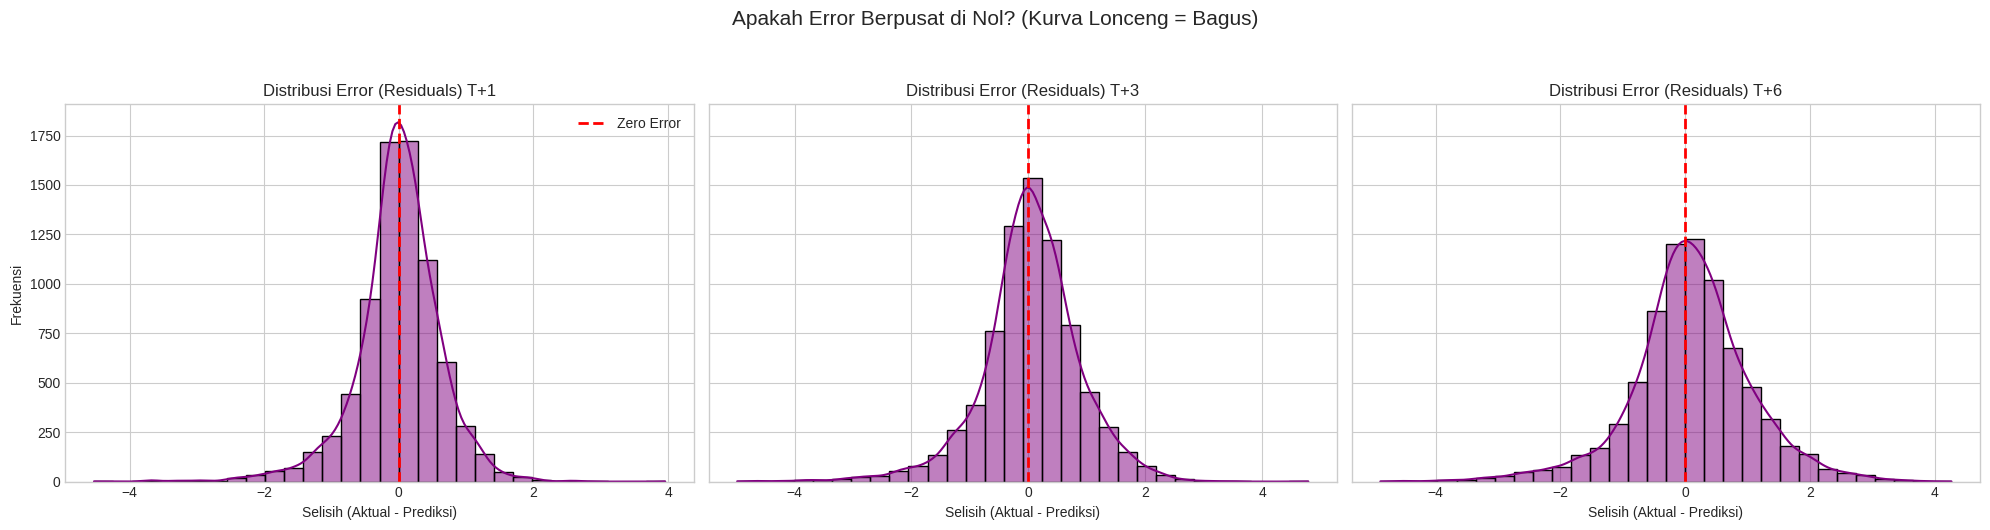

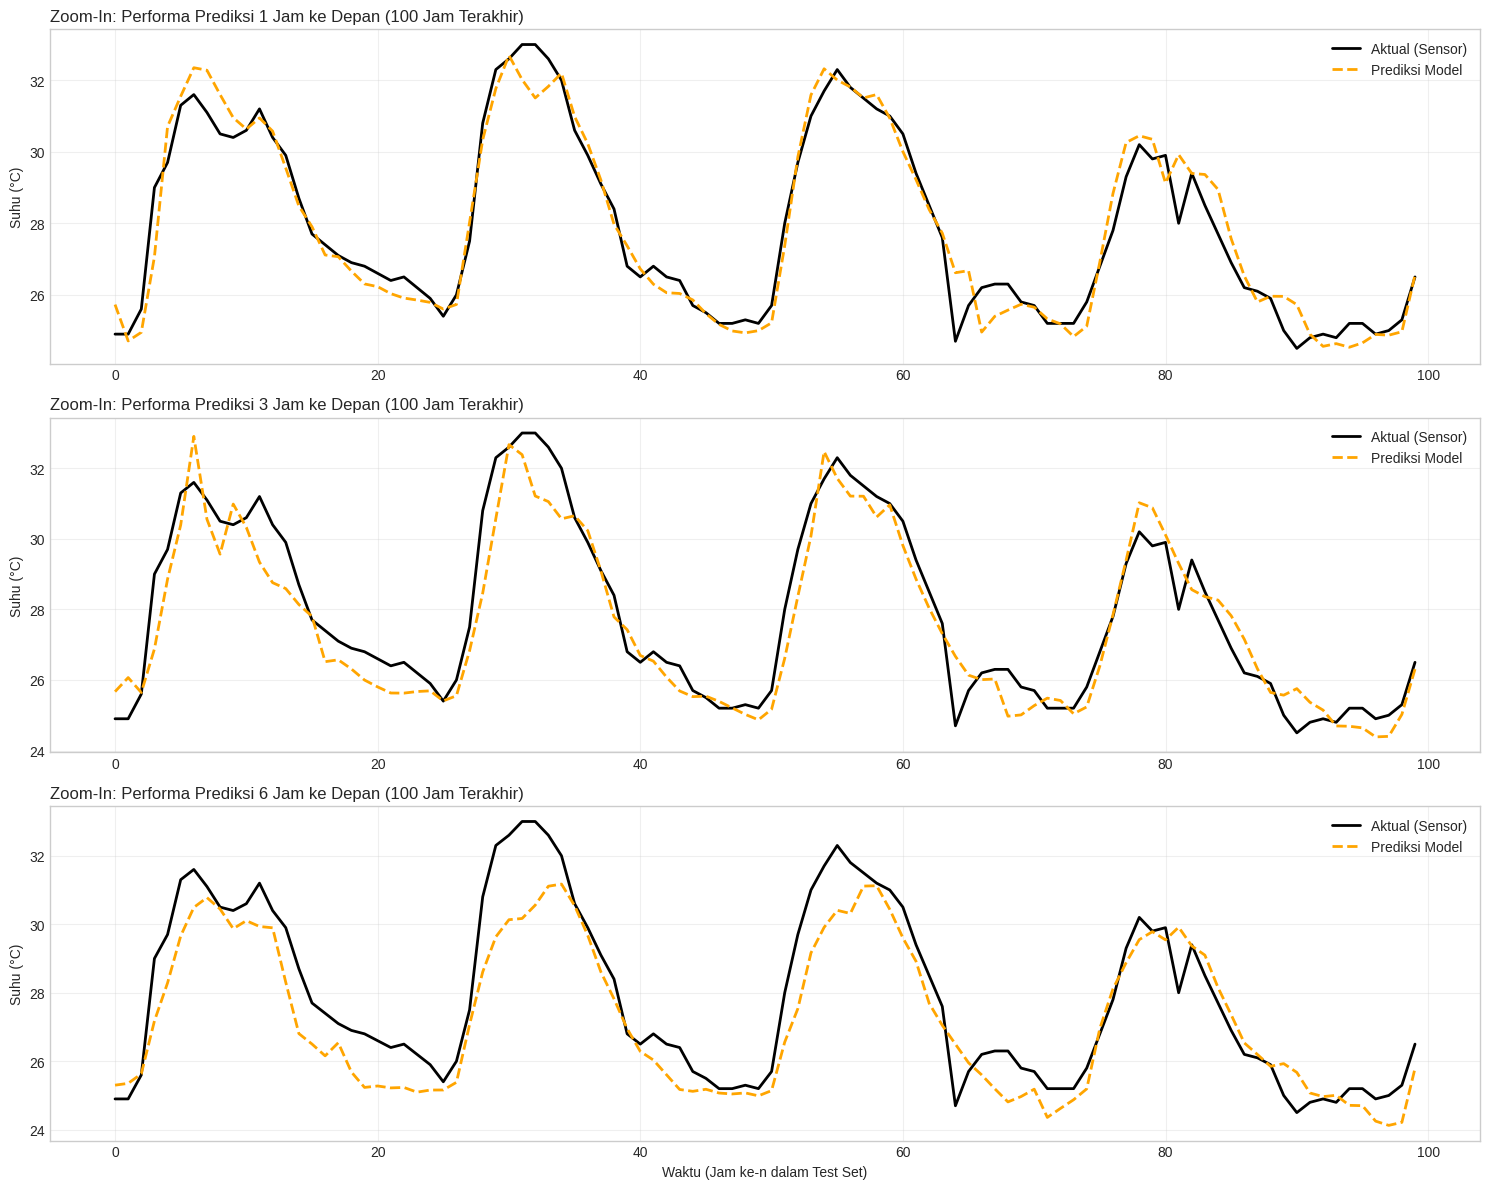

In [ ]:
# Pastikan style grafik terlihat bagus
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# PLOT 1: PERBANDINGAN MAE PER HORIZON
# ==========================================
# Tujuannya: Melihat seberapa drastis penurunan akurasi di masa depan
horizons = list(results.keys())
mae_scores = [results[h]['mae'] for h in horizons]

plt.figure(figsize=(10, 5))
bars = plt.bar([f'T+{h} Jam' for h in horizons], mae_scores, color=['#4c72b0', '#55a868', '#c44e52'])

# Tambahkan angka di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}°C', ha='center', va='bottom', fontweight='bold')

plt.title('Kenaikan Error (MAE) Berdasarkan Jarak Prediksi', fontsize=14)
plt.ylabel('Mean Absolute Error (°C)')
plt.xlabel('Horizon Waktu')
plt.ylim(0, max(mae_scores) * 1.2) # Beri ruang di atas
plt.show()

# ==========================================
# PLOT 2: DISTRIBUSI RESIDUAL (ERROR)
# ==========================================
# Tujuannya: Mengecek apakah model "Bias" (terlalu sering menebak ketinggian/kerendahan)
# Residual = Aktual - Prediksi

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for i, h in enumerate(horizons):
    y_true = results[h]['y_true']
    y_pred = results[h]['y_pred']
    residuals = y_true - y_pred

    sns.histplot(residuals, kde=True, ax=axes[i], color='purple', bins=30)
    axes[i].axvline(0, color='red', linestyle='--', lw=2, label='Zero Error')
    axes[i].set_title(f'Distribusi Error (Residuals) T+{h}', fontsize=12)
    axes[i].set_xlabel('Selisih (Aktual - Prediksi)')
    if i == 0:
        axes[i].set_ylabel('Frekuensi')
        axes[i].legend()

plt.suptitle('Apakah Error Berpusat di Nol? (Kurva Lonceng = Bagus)', y=1.05, fontsize=15)
plt.tight_layout()
plt.show()

# ==========================================
# PLOT 3: LINE PLOT (ACTUAL VS PREDICTED)
# ==========================================
# Tujuannya: Melihat seberapa baik model mengikuti pola naik-turun
# Kita hanya ambil 100 jam terakhir agar grafik tidak ruwet

zoom_last_n = 100  # Lihat 100 data terakhir saja

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for i, h in enumerate(horizons):
    y_true = results[h]['y_true'][-zoom_last_n:]
    y_pred = results[h]['y_pred'][-zoom_last_n:]

    # Reset index agar bisa di-plot berurutan
    y_true = y_true.reset_index(drop=True)
    y_pred = pd.Series(y_pred, index=y_true.index)

    ax = axes[i]
    ax.plot(y_true, label='Aktual (Sensor)', color='black', linewidth=2)
    ax.plot(y_pred, label='Prediksi Model', color='orange', linestyle='--', linewidth=2)

    ax.set_title(f'Zoom-In: Performa Prediksi {h} Jam ke Depan (100 Jam Terakhir)', fontsize=12, loc='left')
    ax.set_ylabel('Suhu (°C)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.xlabel('Waktu (Jam ke-n dalam Test Set)')
plt.tight_layout()
plt.show()

### XGBoost Classifier

##### Hyperparameter Tuning

In [ ]:
model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5, 1],
    'min_child_weight': [1, 3, 5]
}


random_search_rain = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)


random_search_rain.fit(X_train_class, y_train_class)


print("\nParameter Terbaik:")
print(random_search_rain.best_params_)

print(f"\nSkor F1-Macro Terbaik: {random_search_rain.best_score_:.4f}")

# Simpan parameter terbaik ke variabel untuk dipakai di model final
best_rain_params = random_search_rain.best_params_

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Parameter Terbaik:
{'subsample': 0.6, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}

Skor F1-Macro Terbaik: 0.5783


In [ ]:
rain_horizons = [1, 3, 6]
final_rain_models = {}

# Gunakan fitur yang SUDAH DISELEKSI
for h in rain_horizons:
    print(f"Training Model Final T+{h}...")

    # Target & Fitur
    y_train_h = train_df['Kelas_Hujan'].shift(-h).dropna()
    y_val_h   = val_df['Kelas_Hujan'].shift(-h).dropna()

    X_train_h = train_df.loc[y_train_h.index][selected_features]
    X_val_h   = val_df.loc[y_val_h.index][selected_features]

    # Training
    model = xgb.XGBClassifier(
        **best_rain_params,
        objective='multi:softprob', num_class=3, random_state=42, n_jobs=-1
    )
    model.fit(
        X_train_h, y_train_h,
        verbose=False
    )
    final_rain_models[h] = model

Training Model Final T+1...
Training Model Final T+3...
Training Model Final T+6...


In [ ]:
for h in rain_horizons:
    print(f"\n--- Evaluasi T+{h} (Test Set) ---")
    y_test_h = test_df['Kelas_Hujan'].shift(-h).dropna()
    X_test_h = test_df.loc[y_test_h.index][selected_features]

    preds = final_rain_models[h].predict(X_test_h)

    print(classification_report(y_test_h, preds,
                                target_names=['Cerah', 'Ringan', 'Lebat'],
                                zero_division=0))


--- Evaluasi T+1 (Test Set) ---
              precision    recall  f1-score   support

       Cerah       0.87      0.89      0.88      4763
      Ringan       0.77      0.76      0.77      2768
       Lebat       0.36      0.05      0.08        84

    accuracy                           0.83      7615
   macro avg       0.67      0.57      0.58      7615
weighted avg       0.83      0.83      0.83      7615


--- Evaluasi T+3 (Test Set) ---
              precision    recall  f1-score   support

       Cerah       0.79      0.81      0.80      4762
      Ringan       0.64      0.64      0.64      2767
       Lebat       0.00      0.00      0.00        84

    accuracy                           0.74      7613
   macro avg       0.48      0.48      0.48      7613
weighted avg       0.73      0.74      0.73      7613


--- Evaluasi T+6 (Test Set) ---
              precision    recall  f1-score   support

       Cerah       0.78      0.78      0.78      4762
      Ringan       0.61      0

## Save Model

In [ ]:
# Buat folder models jika belum ada
if not os.path.exists('models'):
    os.makedirs('models')

print("Menyimpan model ke folder 'models/'...")

# Simpan 3 model terpisah
joblib.dump(models[1], 'models/suhu_1h.pkl')
joblib.dump(models[3], 'models/suhu_3h.pkl')
joblib.dump(models[6], 'models/suhu_6h.pkl')

for h in rain_horizons:
    joblib.dump(final_rain_models[h], f'models/hujan_{h}h.pkl')

Menyimpan model ke folder 'models/'...


['models/suhu_6h.pkl']